# Document Visual question answering

 - **Model**: Qwen3-VL-32B-Instruct
 - **Dataset**: DocVQA

# 0. Install Dependencies

In [1]:
!pip install -q unsloth trl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 209.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 172.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install -q deepeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.1/824.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 4.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd '/content/drive/MyDrive/Fine-Tuning/Prism'

/content/drive/MyDrive/Fine-Tuning/Prism


# 1. Load and Explore DocVQA Dataset

In [5]:
from datasets import load_dataset

dataset = load_dataset("nielsr/docvqa_1200_examples")

print(f"Train:     {len(dataset['train'])} example")
print(f"Test:      {len(dataset['test'])} examples")
print(f"\tColumns: {dataset['train'].column_names}")

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-f795527aa19f0f(…):   0%|          | 0.00/123M [00:00<?, ?B/s]

data/test-00000-of-00001-41a63b2e1b4ecc5(…):   0%|          | 0.00/25.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/200 [00:00<?, ? examples/s]

Train:     1000 example
Test:      200 examples
	Columns: ['id', 'image', 'query', 'answers', 'words', 'bounding_boxes', 'answer']


In [6]:
# First few examples
ex = dataset['train'][0]
print("\nFirst Example:")
print(f"\tQuery:      {ex['query']['en']}")
print(f"\tAnswers:    {ex['answers']}")
print(f"\tImage size: {ex['image'].size}")


First Example:
	Query:      what is the date mentioned in this letter?
	Answers:    ['1/8/93']
	Image size: (1695, 2025)


In [7]:
# Answer analysis
all_answers = [ans[0] for ans in dataset['train']['answers'] if ans]
lengths = [len(a.split()) for a in all_answers]

print(f"Answer length (words): min={min(lengths)}, median={sorted(lengths)[len(lengths)//2]}, max={max(lengths)}")
print(f"Average answer length: {sum(lengths)/len(lengths):.1f} words")

# Sample Q&A pairs
print("\nSample Questions:")
for i in range(5):
  ex = dataset['train'][i]
  print(f"\tQuestion: {ex['query']['en']}")
  print(f"\tAnswer:   {ex['answers'][0]}", end="\n")

Answer length (words): min=1, median=3, max=30
Average answer length: 3.1 words

Sample Questions:
	Question: what is the date mentioned in this letter?
	Answer:   1/8/93
	Question: Who is in  cc in this letter?
	Answer:   T.F. Riehl
	Question: what is the subject of  this letter?
	Answer:   Review of existing Brainstorming Ideas/483
	Question: What is the number at the bottom of the page, in bold?
	Answer:   499150498
	Question: How many points are there in modifications to readout instrumentation
	Answer:   5.


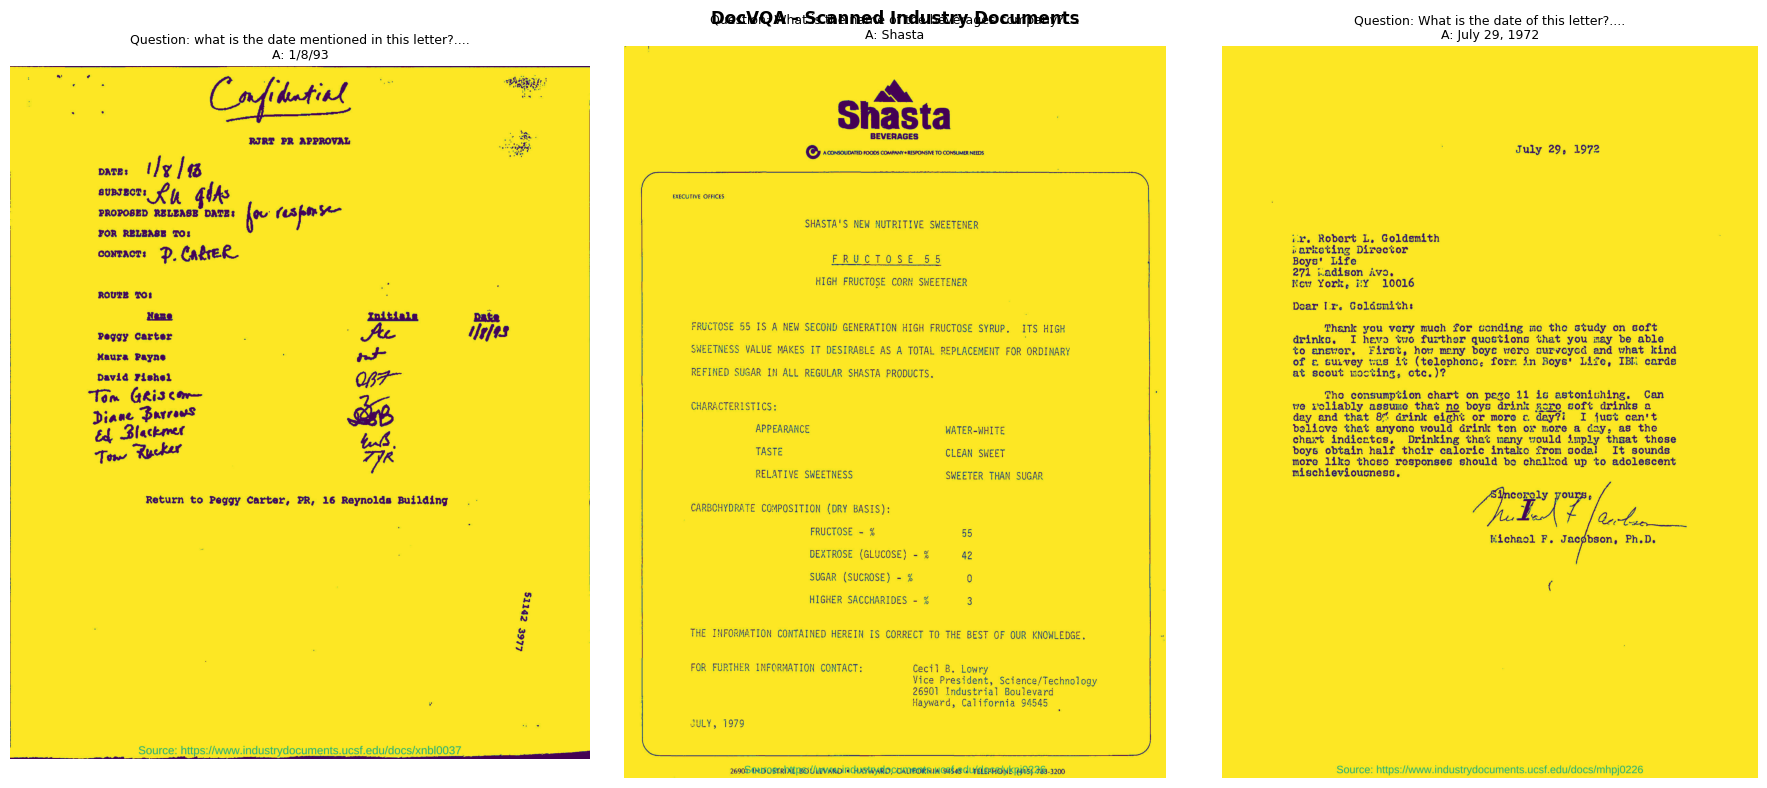

In [8]:
# visualizing sample document
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3,figsize=(18, 8))
for i, ax in enumerate(axes):
  ex = dataset['train'][i * 100]
  ax.imshow(ex['image'])
  q = ex['query']['en']
  a = ex['answers'][0]
  ax.set_title(f"Question: {q[:55]}....\nA: {a[:50]}", fontsize=9)
  ax.axis("off")

plt.suptitle("DocVQA - Scanned Industry Documents", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Format Dataset For VLM Training

In [9]:
SYSTEM_PROMPT = (
    """
    You are a document analysis assistant. Examine the provided document image
    and answer the question accurately and concisely based on the text and layout
    visible in the document.
    """
)

def format_docvqa_example(example):
  """Convert a DocVQA example into Unsloth's conversation format."""
  answer = example['answers'][0] if example['answers'] else ""
  question = example['query']['en'] if isinstance(example['query'], dict) else example['query']

  return {
      "messages": [
          {
              "role": "system",
              "content": [{"type": "text", "text": SYSTEM_PROMPT}],
          },
          {
              "role": "user",
              "content": [
                  {"type": "image", "image": example['image']},
                  {"type": "text", "text": question},
              ],
          },
          {
              "role": "assistant",
              "content": [{"type": "text", "text": answer}],
          },
      ]
  }

In [10]:
train_data = [format_docvqa_example(ex) for ex in dataset['train']]
test_data = [format_docvqa_example(ex) for ex in dataset['test']]

print(f"Formatted {len(train_data)} training examples")
print(f"Formatted {len(test_data)} test examples")

Formatted 1000 training examples
Formatted 200 test examples


# 3. Load Model and Apply LoRA

In [11]:
from unsloth import FastVisionModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [24]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

==((====))==  Unsloth 2026.2.1: Fast Qwen3_Vl patching. Transformers: 4.57.6.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [25]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=128,
    lora_alpha=256,
    lora_dropout=0,
    bias="none",
    random_state=47,
    use_rslora=False,
    loftq_config=None,
)

In [26]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M ({trainable/total*100:.2f}%)")

Trainable: 349.2M / 5802.8M (6.02%)


# 4. Baseline Evaluation

In [15]:
!uv pip install -q -U qwen-vl-utils

In [16]:
from qwen_vl_utils import process_vision_info

def generate_answer(model, tokenizer, image, question, max_tokens=64):
    """Run inference on one or more image+question pairs.

    Returns:
        - str for single input
        - list[str] for batched input
    """
    image_is_batch = isinstance(image, (list, tuple))
    question_is_batch = isinstance(question, (list, tuple))
    single_input = not image_is_batch and not question_is_batch

    images = list(image) if image_is_batch else [image]
    questions = list(question) if question_is_batch else [question] * len(images)

    if len(images) != len(questions):
        raise ValueError("image and question must have the same length.")
    if not images:
        return "" if single_input else []

    messages_batch = [
        [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img},
                    {"type": "text", "text": q},
                ],
            },
        ]
        for img, q in zip(images, questions)
    ]

    input_texts = [
        tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        for messages in messages_batch
    ]

    image_inputs = []
    video_inputs = []
    has_any_video = False
    for messages in messages_batch:
        imgs, vids = process_vision_info(messages)
        if imgs is not None:
            image_inputs.extend(imgs)
        if vids is not None:
            video_inputs.extend(vids)
            has_any_video = True

    tokenizer_kwargs = {
        "text": input_texts,
        "images": image_inputs,
        "padding": True,
        "return_tensors": "pt",
    }
    if has_any_video:
        tokenizer_kwargs["videos"] = video_inputs

    inputs = tokenizer(**tokenizer_kwargs).to(model.device)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.1,
            do_sample=False,
        )

    prompt_lengths = inputs["attention_mask"].sum(dim=1).tolist()
    predictions = [
        tokenizer.decode(
            output_ids[i][int(prompt_lengths[i]):],
            skip_special_tokens=True,
        ).strip()
        for i in range(len(input_texts))
    ]

    return predictions[0] if single_input else predictions

In [17]:
def _normalize_text(text):
    """Normalize text once for fair/faster matching."""
    return " ".join(str(text).lower().strip().split())


def _levenshtein_distance(a, b):
    """Memory-efficient Levenshtein distance using two rows (O(min(m, n)) space)."""
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)

    # Keep b as the shorter string to reduce memory.
    if len(a) < len(b):
        a, b = b, a

    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i]
        for j, cb in enumerate(b, start=1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            replace_cost = previous[j - 1] + (ca != cb)
            current.append(min(insert_cost, delete_cost, replace_cost))
        previous = current

    return previous[-1]


def normalized_levenshtein_similarity(pred, gold):
    """ANLS metric (DocVQA): normalized Levenshtein with 0.5 cutoff."""
    pred_norm = _normalize_text(pred)
    gold_norm = _normalize_text(gold)

    if not pred_norm and not gold_norm:
        return 1.0
    if not pred_norm or not gold_norm:
        return 0.0

    dist = _levenshtein_distance(pred_norm, gold_norm)
    nls = 1 - dist / max(len(pred_norm), len(gold_norm))
    return nls if nls >= 0.5 else 0.0


def compute_anls(results):
    """Compute ANLS over all results using best match across acceptable answers."""
    if not results:
        return 0.0

    total = 0.0
    for r in results:
        pred_norm = _normalize_text(r["prediction"])
        answers = r["answers"] if isinstance(r["answers"], list) else [r["answers"]]

        best = 0.0
        for a in answers:
            gold_norm = _normalize_text(a)

            if not pred_norm and not gold_norm:
                score = 1.0
            elif not pred_norm or not gold_norm:
                score = 0.0
            else:
                dist = _levenshtein_distance(pred_norm, gold_norm)
                score = 1 - dist / max(len(pred_norm), len(gold_norm))
                if score < 0.5:
                    score = 0.0

            if score > best:
                best = score
                if best == 1.0:
                    break

        total += best

    return total / len(results)


def compute_exact_match(results):
    """Strict exact match against any acceptable answer."""
    if not results:
        return 0.0

    correct = 0
    for r in results:
        pred_norm = _normalize_text(r["prediction"])
        answers = r["answers"] if isinstance(r["answers"], list) else [r["answers"]]
        if any(pred_norm == _normalize_text(a) for a in answers):
            correct += 1

    return correct / len(results)

In [18]:
import random

random.seed(42)
N_EVAL = min(100, len(dataset['test']))
eval_indices = random.sample(range(len(dataset['test'])), N_EVAL)
eval_subset = [dataset['test'][i] for i in eval_indices]

print(f"Running baseline evaluation on {len(eval_subset)} test examples...")

FastVisionModel.for_inference(model)

BATCH_SIZE = 8
baseline_results = []
for start in range(0, len(eval_subset), BATCH_SIZE):
    batch = eval_subset[start:start + BATCH_SIZE]
    questions = [ex['query']['en'] if isinstance(ex['query'], dict) else ex['query'] for ex in batch]
    images = [ex['image'] for ex in batch]

    preds = generate_answer(model, tokenizer, images, questions)

    for ex, question, pred in zip(batch, questions, preds):
        baseline_results.append({
            'question': question,
            'answers': ex['answers'],
            'prediction': pred,
        })

    end = min(start + BATCH_SIZE, len(eval_subset))
    if end % 20 == 0 or end == len(eval_subset):
        print(f"  {end}/{len(eval_subset)} done")

Running baseline evaluation on 100 test examples...
  40/100 done
  80/100 done
  100/100 done


In [19]:
baseline_anls = compute_anls(baseline_results)
baseline_em = compute_exact_match(baseline_results)
print(f"\nBaseline (zero-shot):")
print(f"  ANLS:        {baseline_anls:.3f}")
print(f"  Exact Match: {baseline_em:.1%}")


Baseline (zero-shot):
  ANLS:        0.010
  Exact Match: 1.0%


In [20]:
# Sample baseline predictions to understand failure modes
print("Sample Baseline predictions:\n")
for r in baseline_results[:6]:
  gold = r['answers'][0] if isinstance(r['answers'], list) else r['answers']
  nls = normalized_levenshtein_similarity(r['prediction'], gold)
  status = "[CORRECT]" if nls >= 0.5 else "[INCORRECT]"
  print(f"\t{status}  (ANLS={nls:.2f})")
  print(f"\tQuestion: {r['question']}")
  print(f"\tGold:     {gold}")
  print(f"\tPred:     {r['prediction'][:80]}", end="\n")

Sample Baseline predictions:

	[INCORRECT]  (ANLS=0.00)
	Question: which is his next destination after china ?
	Gold:     Hongkong
	Pred:     which is his next destination after china ?
assistant
Based on the information p
	[INCORRECT]  (ANLS=0.00)
	Question: What are the 2 lifestyle & apparel brands of ITC?
	Gold:     Wills Lifestyle and John Players
	Pred:     What are the 2 lifestyle & apparel brands of ITC?
assistant
Based on the text pr
	[INCORRECT]  (ANLS=0.00)
	Question: What is the committee strength for the sustainability committee meeting held on 5th April, 2012?
	Gold:     6
	Pred:     What is the committee strength for the sustainability committee meeting held on 
	[INCORRECT]  (ANLS=0.00)
	Question: What is the percentage of net pounds out over net pounds infeed (handwritten)?
	Gold:     83.4%
	Pred:     What is the percentage of net pounds out over net pounds infeed (handwritten)?
a
	[INCORRECT]  (ANLS=0.00)
	Question: What is the monthly actual towards office rent?
	Gold

# 5. Fine-Tuned Training Model

In [21]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [27]:
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_data,
    args=SFTConfig(
        per_device_train_batch_size=8,
        gradient_accumulation_steps=8,
        warmup_steps=10,
        num_train_epochs=3,
        learning_rate=2e-4,
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=47,
        output_dir="./outputs_dir/Qwen3_VL_32B_Instruct_DocVQA",
        report_to="none",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_seq_length=2048,
    ),
)

print("Trainer Initialized!")

Unsloth: Model does not have a default image size - using 512
Trainer Initialized!


In [28]:
trainer_stats = trainer.train()
print("\nTraining Completed!")
print(f"\tTotal steps: {trainer_stats.global_step}")
print(f"\tFinal loss: {trainer_stats.training_loss:.4f}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 3 | Total steps = 48
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 8 x 1) = 64
 "-____-"     Trainable parameters = 349,175,808 of 9,116,299,504 (3.83% trained)


Step,Training Loss
10,1.442200
20,0.245800
30,0.230300
40,0.194600



Training Completed!
	Total steps: 48
	Final loss: 0.4676


# 6. Save Model

In [30]:
import gc
import torch

SAVE_DIR = "./model/Qwen3-vl-8b-instruct-document-vqa"
ADAPTER_DIR = SAVE_DIR + "-lora"
BASE_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"

def _clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

saved_merged = False

# 1) Fast path: merge directly from the in-memory PEFT model.
try:
    merged_model = model.merge_and_unload()
    merged_model.save_pretrained(
        SAVE_DIR,
        safe_serialization=True,
        max_shard_size="2GB",
    )
    tokenizer.save_pretrained(SAVE_DIR)
    saved_merged = True
    print(f"Saved merged model to {SAVE_DIR}")

except Exception as e:
    print(f"Direct merge_and_unload() failed: {e}")

    # 2) Always save adapters so training output is not lost.
    model.save_pretrained(ADAPTER_DIR, safe_serialization=True)
    tokenizer.save_pretrained(ADAPTER_DIR)
    print(f"Saved LoRA adapter checkpoint to {ADAPTER_DIR}")

    # 3) Best-effort retry: reload full-precision base, apply LoRA, then merge.
    try:
        from peft import PeftModel
        from unsloth import FastVisionModel

        _clear_vram()
        base_model, _ = FastVisionModel.from_pretrained(
            BASE_MODEL_ID,
            load_in_4bit=False,
            use_gradient_checkpointing=False,
        )
        base_with_lora = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
        merged_model = base_with_lora.merge_and_unload()

        merged_model.save_pretrained(
            SAVE_DIR,
            safe_serialization=True,
            max_shard_size="2GB",
        )
        tokenizer.save_pretrained(SAVE_DIR)
        saved_merged = True
        print(f"Saved merged model to {SAVE_DIR} (adapter applied to base and merged).")

    except Exception as e2:
        print("Could not create merged checkpoint in this runtime.")
        print(f"You can still use adapter-only checkpoint at: {ADAPTER_DIR}")
        print(f"Merge retry error: {e2}")

if saved_merged:
    print("Final artifact: merged model safetensors + tokenizer.")
else:
    print("Final artifact: adapter safetensors + tokenizer (merge can be done later).")

Saved merged model to ./model/Qwen3-vl-8b-instruct-document-vqa
Final artifact: merged model safetensors + tokenizer.


# 6. Post Training Evaluation

In [ ]:
import gc
import torch

# Delete big objects if they exist
for name in [
    "model", "merged_model", "trainer", "optimizer", "lr_scheduler",
    "tokenizer", "inputs", "outputs", "batch", "loss"
]:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()   # helps release inter-process cached memory
    free, total = torch.cuda.mem_get_info()
    print(f"GPU free: {free/1024**3:.2f} GB / {total/1024**3:.2f} GB")

GPU free: 64.02 GB / 94.97 GB


In [ ]:
import os
import gc
import torch

SAVE_DIR = "./model/Qwen3_VL_32B_DocVQA"
ADAPTER_DIR = SAVE_DIR + "-lora"
BASE_MODEL_ID = "Qwen/Qwen3-VL-32B-Instruct"  # required if adapter-only load

# ---------- Save ----------
saved_path = None
try:
    merged_model = model.merge_and_unload()
    merged_model.save_pretrained(
        SAVE_DIR,
        safe_serialization=True,
        max_shard_size="4GB",
    )
    tokenizer.save_pretrained(SAVE_DIR)
    saved_path = SAVE_DIR
    print(f"Saved merged model to: {SAVE_DIR}")
except Exception as e:
    print(f"merge_and_unload failed: {e}")
    model.save_pretrained(ADAPTER_DIR, safe_serialization=True)
    tokenizer.save_pretrained(ADAPTER_DIR)
    saved_path = ADAPTER_DIR
    print(f"Saved adapter-only checkpoint to: {ADAPTER_DIR}")

# Free memory before reload
for var_name in ["merged_model", "model"]:
    if var_name in globals():
        del globals()[var_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ---------- Load ----------
def load_saved_vlm(path, base_model_id=None, load_in_4bit=True):
    # Adapter-only checkpoint
    if os.path.exists(os.path.join(path, "adapter_config.json")):
        if base_model_id is None:
            raise ValueError("base_model_id is required to load adapter-only checkpoints.")
        from unsloth import FastVisionModel
        from peft import PeftModel

        base_model, tok = FastVisionModel.from_pretrained(
            model_name=base_model_id,
            load_in_4bit=load_in_4bit,
            use_gradient_checkpointing=False,
        )
        model_loaded = PeftModel.from_pretrained(base_model, path, is_trainable=False)
        FastVisionModel.for_inference(model_loaded)
        return model_loaded, tok, "adapter"

    # Merged/full checkpoint
    from transformers import AutoProcessor
    try:
        from transformers import AutoModelForImageTextToText as AutoVLM
    except Exception:
        from transformers import AutoModelForVision2Seq as AutoVLM

    tok = AutoProcessor.from_pretrained(path, trust_remote_code=True)
    model_loaded = AutoVLM.from_pretrained(
        path,
        trust_remote_code=True,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    model_loaded.eval()
    return model_loaded, tok, "merged"

model, tokenizer, ckpt_type = load_saved_vlm(
    saved_path,
    base_model_id=BASE_MODEL_ID,
    load_in_4bit=True,  # only used for adapter-only load
)

print(f"Reloaded {ckpt_type} checkpoint from: {saved_path}")

In [31]:
FastVisionModel.for_inference(model)

print(f"Running fine-tuned evaluation on {len(eval_subset)} test examples...")

BATCH_SIZE = globals().get("BATCH_SIZE", 8)
finetuned_results = []
for start in range(0, len(eval_subset), BATCH_SIZE):
    batch = eval_subset[start:start + BATCH_SIZE]
    questions = [ex['query']['en'] if isinstance(ex['query'], dict) else ex['query'] for ex in batch]
    images = [ex['image'] for ex in batch]

    preds = generate_answer(model, tokenizer, images, questions)

    for ex, question, pred in zip(batch, questions, preds):
        finetuned_results.append({
            'question': question,
            'answers': ex['answers'],
            'prediction': pred,
        })

    end = min(start + BATCH_SIZE, len(eval_subset))
    if end % 20 == 0 or end == len(eval_subset):
        print(f"  {end}/{len(eval_subset)} done")

Running fine-tuned evaluation on 100 test examples...
  40/100 done
  80/100 done
  100/100 done


In [32]:
finetuned_anls = compute_anls(finetuned_results)
finetuned_em = compute_exact_match(finetuned_results)

In [33]:
# Side-by-side comparison
print("\n" + "="*55)
print("BASELINE vs FINE-TUNED")
print("="*55)
print(f"{'Metric':<25} {'Baseline':>10} {'Fine-tuned':>12} {'Delta':>10}")
print("-"*58)

for name, base, ft in [("ANLS", baseline_anls, finetuned_anls), ("Exact Match", baseline_em, finetuned_em)]:
    delta = ft - base
    arrow = "↑" if delta > 0 else "↓" if delta < 0 else "→"
    print(f"{name:<25} | {base:>9.3f} | {ft:>11.3f} {arrow} | {abs(delta):>8.3f}")


BASELINE vs FINE-TUNED
Metric                      Baseline   Fine-tuned      Delta
----------------------------------------------------------
ANLS                      |     0.010 |       0.645 ↑ |    0.635
Exact Match               |     0.010 |       0.630 ↑ |    0.620


# 7. LLM-AS-JUDGE - Document Extraction Correctness

In [36]:
import os
from dotenv import load_dotenv

load_dotenv()
try:
  os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
  print("OPENAI_API_KEY loaded successfully!")
except Exception as e:
  print(f"Error loading env variable(s): {e}")

OPENAI_API_KEY loaded successfully!


In [38]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

doc_correctness = GEval(
    name="Document Extraction Correctness",
    criteria=(
        """
        Evaluate Whether the predicted answer correctly extracts the requested
        information from a document image. Consider:
        1) Does the extracted text match the reference answer in meaning/semantics?
        2) Are dates, names, and numbers accurate?
        3) Minor formatting difference (eg: 'Jan' vs 'January') should not be penalized.
        """
    ),
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    model="gpt-4o-mini",
    threshold=0.6,
)

In [40]:
eval_geval = finetuned_results[:30]
print(f"Running GEval on {len(eval_geval)} predictions ....")

geval_scores = []
skipped_empty = 0

for r in eval_geval:
  gold = r['answers'][0] if isinstance(r['answers'], list) else r['answers']

  # DeepEval requires non-empty actual_output/expected_output
  pred = str(r.get('prediction', '')).strip()
  gold = str(gold).strip()
  question = str(r.get('question', '')).strip() or "Document question"

  if not pred or not gold:
    skipped_empty += 1
    continue

  test_case = LLMTestCase(
      input=question,
      actual_output=pred,
      expected_output=gold,
  )
  doc_correctness.measure(test_case, _show_indicator=False)
  geval_scores.append(doc_correctness.score)

if not geval_scores:
  raise ValueError("No valid GEval cases to score (all had empty prediction/answer).")

avg_score = sum(geval_scores) / len(geval_scores)
passing = sum(1 for s in geval_scores if s >= 0.6) / len(geval_scores)
print("\nGEval Document Extraction correctness:")
print(f"\tAverage score:     {avg_score:.3f}")
print(f"\tPass rate (>=0.6): {passing:.1%}")
print(f"\tScored: {len(geval_scores)} / {len(eval_geval)} | Skipped empty: {skipped_empty}")

Running GEval on 30 predictions ....

GEval Document Extraction correctness:
	Average score:     0.977
	Pass rate (>=0.6): 100.0%
	Scored: 15 / 30 | Skipped empty: 15


# 8. Error Analysis

In [41]:
import re

def classify_answer(answer):
  answer = answer.strip()
  if re.match(r'^[\d,.$%]+$', answer.replace(' ', '')):
    return "numeric"
  if re.match(r'.*\d{1,2}[/-]\d{1,2}[/-]\d{2,4}.*', answer):
    return "date"
  if len(answer.split()) <= 2:
    return "short_text"
  return "long_text"

# Breakdown by categories
categories = {}
for r in finetuned_results:
  gold = r['answers'][0] if isinstance(r['answers'], list) else r['answers']
  cat = classify_answer(gold)
  if cat not in categories:
    categories[cat] = {'correct': 0, 'total': 0, 'anls_sum': 0}
  categories[cat]['total'] += 1
  nls = max(normalized_levenshtein_similarity(r['prediction'], a)
            for a in (r['answers'] if isinstance(r['answers'], list) else [r['answers']]))
  categories[cat]['anls_sum'] += nls
  if nls >= 0.5:
    categories[cat]['correct'] += 1

In [42]:
print("Performance by answer category:\n")
print(f"{'Category':<15} | {'Count':>6} | {'ANLS':>8} | {'Acc (>=0.5)':>12}")
print("="*50)
for cat, stats in sorted(categories.items()):
  anls = stats['anls_sum'] / stats['total']
  acc = stats['correct'] / stats['total']
  print(f"{cat:<15} | {stats['total']:>6} | {anls:>7.3f} | {acc:>11.1%}")

Performance by answer category:

Category        |  Count |     ANLS |  Acc (>=0.5)
date            |      1 |   0.000 |        0.0%
long_text       |     29 |   0.515 |       51.7%
numeric         |     36 |   0.667 |       66.7%
short_text      |     34 |   0.750 |       76.5%


In [44]:
# Verbosity analysis - DocVQA answers should be short and extractive
pred_lengths = [len(r['prediction'].split()) for r in finetuned_results]
gold_lengths = [len((r['answers'][0] if isinstance(r['answers'], list) else r['answers']).split())
                for r in finetuned_results]

avg_pred = sum(pred_lengths) / len(pred_lengths)
avg_gold = sum(gold_lengths) / len(gold_lengths)

print("Answer Verbosity:")
print(f"\tGold avg length: {avg_gold:.1f} words")
print(f"\tPred avg length: {avg_pred:.1f} words")
print(f"\tRatio:           {avg_pred/avg_gold:.1f}x" if avg_gold > 0 else "")

if avg_pred > avg_gold * 3:
  print("\t[CAUTION] Model answers are much more verbose than ground truth answers")

Answer Verbosity:
	Gold avg length: 2.1 words
	Pred avg length: 1.7 words
	Ratio:           0.8x


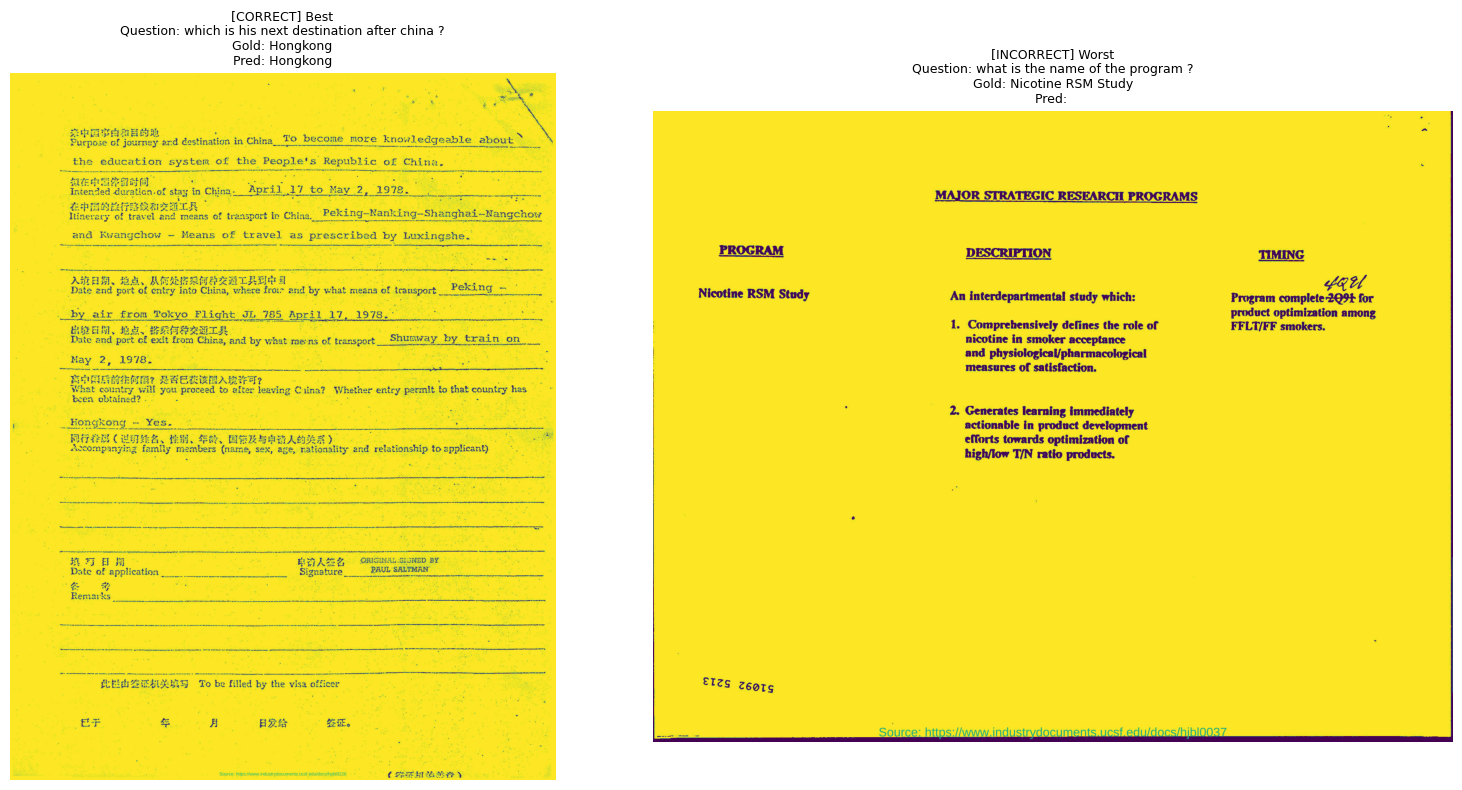

In [45]:
import matplotlib.pyplot as plt

scored = []
for i, r in enumerate(finetuned_results):
  gold = r['answers'][0] if isinstance(r['answers'], list) else r['answers']
  nls = normalized_levenshtein_similarity(r['prediction'], gold)
  scored.append((i, nls))

scored.sort(key=lambda x: x[1], reverse=True)
best_idx = scored[0][0]
worst_idx = scored[-1][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, idx, label in [(axes[0], best_idx, "[CORRECT] Best"), (axes[1], worst_idx, "[INCORRECT] Worst")]:
  ax.imshow(eval_subset[idx]['image'])
  r = finetuned_results[idx]
  gold = r['answers'][0] if isinstance(r['answers'], list) else r['answers']
  ax.set_title(
      f"{label}\nQuestion: {r['question'][:60]}\nGold: {gold[:50]}\nPred: {r['prediction'][:50]}",
      fontsize=9,
  )
  ax.axis("off")

plt.tight_layout()
plt.show()

# Cross Domain Comparison

**Medical VQA vs Document VQA**

In [49]:
phase5_metrics = {
    'closed_accuracy': 0.73,  # e.g. 0.82
    'open_token_f1': 0.28,    # e.g. 0.45
    'geval_score': 0.345,      # e.g. 0.65
}

print("Cross-Domain Comparison: Medica VQA vs Document VQA")
print("="*90)
print(f"\n{'':25} | {'Phase 5':>15} | {'Phase 6':>15}")
print(f"{'':25} | {'Medical VQA':>15} | {'DocVQA':>15}")
print("="*90)
print(f"{'Dataset size':<25} | {'~1800 train':>15} | {'1,000 train':>15}")
print(f"{'Image type':>25} | {'Radiology':>15} | {'Documents':>15}")
print(f"{'Answer style':<25} | {'Clinical terms':>15} | {'Extracted text':>15}")
print(f"{'ANLS':<25} | {'N/A':>15} | {finetuned_anls:>14.3f}")
print(f"{'Exact Match':<25} | {'N/A':>15} | {finetuned_em:>14.1%}")
if phase5_metrics['geval_score']:
    print(f"{'GEval score':<25} | {phase5_metrics['geval_score']:>14.3f} | {avg_score:>14.3f}")

Cross-Domain Comparison: Medica VQA vs Document VQA

                          |         Phase 5 |         Phase 6
                          |     Medical VQA |          DocVQA
Dataset size              |     ~1800 train |     1,000 train
               Image type |       Radiology |       Documents
Answer style              |  Clinical terms |  Extracted text
ANLS                      |             N/A |          0.645
Exact Match               |             N/A |          63.0%
GEval score               |          0.345 |          0.977
